In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import pandas as pd
from data import Olist
olist = Olist()
data = olist.get_data()
orders = data['orders'].copy()

In [35]:
assert(orders.shape == (99441, 8))

In [4]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])


In [6]:
orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']

0        8 days 10:28:40
1       13 days 18:46:08
2        9 days 09:27:40
3       13 days 05:00:36
4        2 days 20:58:23
              ...       
99436    8 days 05:13:56
99437   22 days 04:38:58
99438   24 days 20:37:34
99439   17 days 02:04:27
99440    7 days 16:11:00
Length: 99441, dtype: timedelta64[ns]

In [9]:
one_day_delta = np.timedelta64(24, 'h')
orders.loc[:,'wait_time'] = \
    (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']) / one_day_delta
    
orders.loc[:,'delay_vs_expected'] = \
    (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']) / one_day_delta
    
orders.loc[:,'expected_wait_time'] = \
    (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']) / one_day_delta

In [10]:
(orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

0         8.0
1        13.0
2         9.0
3        13.0
4         2.0
         ... 
99436     8.0
99437    22.0
99438    24.0
99439    17.0
99440     7.0
Length: 99441, dtype: float64

In [11]:
def handle_delay(x):
    if x > 0:
        return x
    else:
        return 0

orders.loc[:,'delay_vs_expected'] = orders['delay_vs_expected'].apply(handle_delay)

In [12]:
orders[['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected']]

,order_id,wait_time,expected_wait_time,delay_vs_expected
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.218009,18.587442,0.0
99437,63943bddc261676b46f01ca7ac2f7bd8,22.193727,23.459051,0.0
99438,83c1379a015df1e13d02aae0204711ab,24.859421,30.384225,0.0
99439,11c177c8e97725db2631073c19f07b62,17.086424,37.105243,0.0


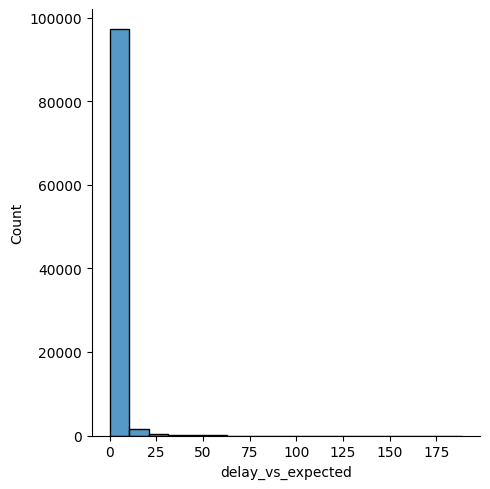

In [16]:
import seaborn as sns

sns.displot(orders['delay_vs_expected'])

In [21]:
test["delay_vs_expected"].min()

0.0

In [22]:
test["delay_vs_expected"].max()

188.97508101851852

In [23]:
test["delay_vs_expected"].dtype

dtype('float64')

In [26]:
from nbresult import ChallengeResult
from order import Order
test = Order().get_wait_time()
result = ChallengeResult('wait_time', dve_type=test["delay_vs_expected"].dtype, shape=test.shape, dve_min=test["delay_vs_expected"].min(), dve_max=test["delay_vs_expected"].max())
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_wait_time.py::TestWaitTime::test_wait_time PASSED                   [100%]

============================== 1 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/wait_time.pickle

git commit -m 'Completed wait_time step'

git push origin master



In [28]:
reviews = data['order_reviews'].copy()
assert(reviews.shape == (99224,7))
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [29]:
one_star = lambda x: int(x==1)
five_star = lambda x: int(x==5)

In [30]:
reviews["dim_is_five_star"] = reviews["review_score"].map(five_star) # --> Series([0, 1, 1, 0, 0, 1 ...])
reviews["dim_is_one_star"] = reviews["review_score"].map(one_star)

In [31]:
reviews[["order_id", "dim_is_five_star", "dim_is_one_star", "review_score"]]

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,1,0,5
99220,22ec9f0669f784db00fa86d035cf8602,1,0,5
99221,55d4004744368f5571d1f590031933e4,1,0,5
99222,7725825d039fc1f0ceb7635e3f7d9206,0,0,4


In [32]:
from nbresult import ChallengeResult
from order import Order
test = Order().get_review_score()
result = ChallengeResult('review_score', shape=Order().get_review_score().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_review_score.py::TestReviewScore::test_review_score PASSED          [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/review_score.pickle

git commit -m 'Completed review_score step'

git push origin master



## get_number_items
order_id, number_of_items (sipariş başına toplam ürün sayısı)

In [47]:
dd = (
    data["order_items"]
    .groupby("order_id")
    .size()
    .reset_index(name="number_of_items")
    .sort_values("number_of_items", ascending=False)
)
dd.columns = ["order_id", "number_of_items"]

In [49]:
dd.shape

(98666, 2)

In [60]:
from nbresult import ChallengeResult
from order import Order
result = ChallengeResult('number_items',
    shape=Order().get_number_items().shape, 
    columns=Order().get_number_items().columns.tolist())
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_number_items.py::TestNumberItems::test_number_items PASSED          [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/number_items.pickle

git commit -m 'Completed number_items step'

git push origin master



### get_number_sellers
order_id, number_of_sellers (sipariş başına benzersiz satıcıların toplam sayısı)


In [62]:
sellers = \
    data['order_items']\
    .groupby('order_id')['seller_id'].nunique().reset_index()

In [64]:
sellers.columns = ['order_id', 'number_of_sellers']
sellers.sort_values('number_of_sellers')

,order_id,number_of_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1
65559,aaaf314a8cf0d0da71e52c6cd4184cbd,1
65558,aaaea350ff8a957595f3c631d6b63d1b,1
65557,aaae80f5b6239bd9e1b22e9aa542c3e8,1
65556,aaabf43feb9498d9de4588eb73231c25,1
...,...,...
11231,1d23106803c48c391366ff224513fb7f,4
53796,8c2b13adf3f377c8f2b06b04321b0925,4
55847,91be51c856a90d7efe86cf9d082d6ae3,4
79967,cf5c8d9f52807cb2d2f0a0ff54c478da,5


In [65]:
sellers.shape

(98666, 2)

In [69]:
from nbresult import ChallengeResult
from order import Order
result = ChallengeResult("number_sellers",
    shape=Order().get_number_sellers().shape, 
    columns=Order().get_number_sellers().columns.tolist())
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_number_sellers.py::TestNumberSellers::test_number_sellers PASSED    [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/number_sellers.pickle

git commit -m 'Completed number_sellers step'

git push origin master



## get_price_and_freight
        order_id, price, freight_value

In [70]:
price_freight = \
    data['order_items']\
    .groupby('order_id',
             as_index=False).agg({'price': 'sum',
                                  'freight_value': 'sum'})
price_freight

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72


In [71]:
price_freight.shape

(98666, 3)

In [73]:
from nbresult import ChallengeResult
from order import Order
result = ChallengeResult("price_and_freight",
    shape=Order().get_price_and_freight().shape, 
    columns=Order().get_price_and_freight().columns.tolist())
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_price_and_freight.py::TestPriceAndFreight::test_price_and_freight PASSED [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/price_and_freight.pickle

git commit -m 'Completed price_and_freight step'

git push origin master



In [81]:
from nbresult import ChallengeResult
from olist.order import Order
data = Order().get_training_data()

result = ChallengeResult('training_data',
    shape=data.shape,
    columns=sorted(list(data.columns))
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/olist/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_training_data.py::TestTrainingData::test_price_and_freight PASSED   [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/training_data.pickle

git commit -m 'Completed training_data step'

git push origin master



In [77]:
from order import Order
order = Order()
training_data = order.get_wait_time(is_delivered=True)

In [79]:
training_data.merge(order.get_review_score(), on="order_id")

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered,0,0,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered,0,0,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered,1,0,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered,1,0,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered,1,0,5
...,...,...,...,...,...,...,...,...
96356,9c5dedf39a927c1b2549525ed64a053c,8.218009,18.587442,0.0,delivered,1,0,5
96357,63943bddc261676b46f01ca7ac2f7bd8,22.193727,23.459051,0.0,delivered,0,0,4
96358,83c1379a015df1e13d02aae0204711ab,24.859421,30.384225,0.0,delivered,1,0,5
96359,11c177c8e97725db2631073c19f07b62,17.086424,37.105243,0.0,delivered,0,0,2
